<a href="https://colab.research.google.com/github/DanielEspinosaArango/Explorando-factores-de-comportamiento-en-NovaRetail-/blob/main/Proyecto_drivers_de_comportamiento_en_NovaRetail%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gastos_publicidad_dirigida`
- `satisfaccion`
- `ingresos_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` tiene tipo de dato `float64` **requiere transformación adicional a `int64`**


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**Diagnóstico inicial de variables numéricas**

- `edad` — (18-75 años), media 38.26, desviación estándar 11.49. Datos limpios, sin valores raros.
- `nivel_ingreso` — (min=8000, max=74790.84). La desviación estándar es de 9833.16, muy alta. Posibles outliers en ingresos altos. Revisar si esos valores extremos son reales.
- `visitas_mes` — (1-25 visitas, media 10). Datos normales.
- `compras_mes` — 25% de los clientes tienen 0 compras. La media es solo 1.21. Hay muchos clientes inactivos o con muy pocas compras.
- `gasto_publicidad_dirigida` — Media 20.15, (min = 0 y max = 75.51) la mayoria de usuarios tiene un gasto en publicidad dirigida de 27.3.
- `satisfaccion` — Escala 1-5, media 3.60, desviación baja (0.685). Clientes moderadamente satisfechos, datos consistentes.
- `ingresos_anual` — Min=0, 25% percentil=0. Hay muchos clientes SIN ingresos registrados. Media 36.59 pero desviación estándar muy alta (34.48). Hay datos faltantes o clientes inactivos aquí.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[['miembro_premium', 'abandono']].nunique()

miembro_premium    2
abandono           2
dtype: int64

**Diagnóstico inicial de variables binarias**

- `miembro_premium` — Se confirma que solamente tiene 2 valores (1, 0)
- `abandono` — Se confirman que solamente tiene 2 valores (1, 0)

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df[['tipo_dispositivo', 'region']].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df['region'].value_counts(normalize=True)*100)
print()
print(df['tipo_dispositivo'].value_counts(normalize=True)*100)

norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64

móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64


**Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — 65.45% de los clientes usan `móvil`, `escritorio` 24.80% y `tablet` solo 9.75%. La mayoría del tráfico es `movil`.
- `región` — Distribución equilibrada entre las 4 regiones. Norte lidera con 29.30%, pero las otras (oeste 25.40%, sur 24.84%, este 20.46%) No hay concentración extrema.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

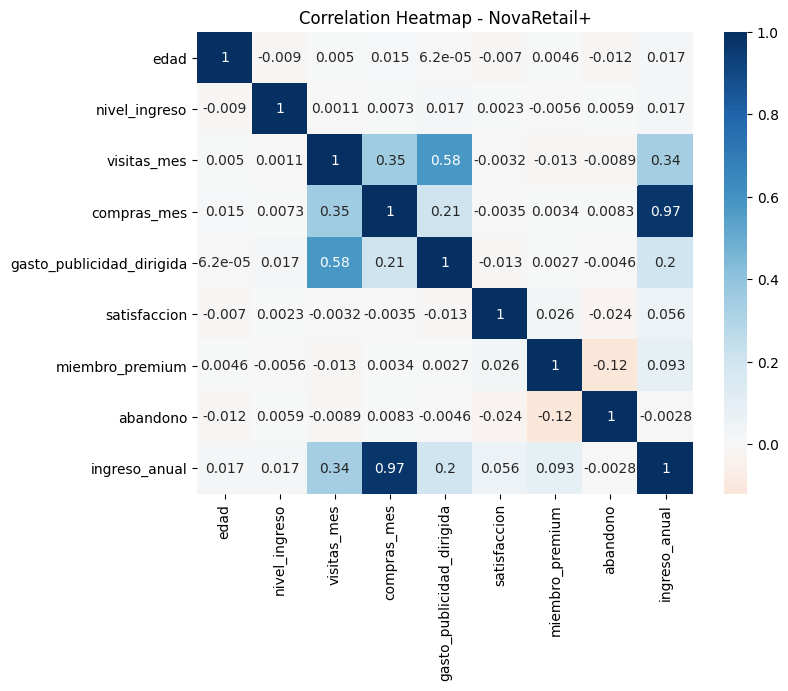

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap - NovaRetail+")
plt.show()

**Observaciones generales (Heatmap)**
- Se observa que:

1. MATRIZ EXTREMADAMENTE DISPERSA

- La mayoría de correlaciones están cercanas a 0 (-0.012 a 0.017 en muchas celdas).
- Casi NO hay relaciones lineales fuertes en los datos.

2. MUY POCAS CORRELACIONES SIGNIFICATIVAS
Solo 3-4 pares de variables tienen correlaciones > 0.3
- `compras_mes vs ingresos_anual: 0.97` CASI PERFECTA. La más fuerte del heatmap.
- `visitas_mes vs gasto_publicidad_dirigida: 0.58` Moderada-fuerte.
- `visitas_mes vs compras_mes: 0.35` Débil-moderada.
- `visitas_mes vs ingresos_anual: 0.34` Débil-moderada.

3. VARIABLES DEMOGRÁFICAS
- `edad`, `nivel_ingreso` NO tienen correlacion (no brindan informacion) (todo cercano a 0).

4. PARADOJA DE SATISFACCIÓN
- satisfaccion está prácticamente desconectada de todo
- Esto sugiere que satisfacción no tiene correlacion con lealtad en este negocio

5. VARIABLES COMPORTAMENTALES
- `visitas`, `compras`, `gasto en publicidad` SÍ correlacionan entre sí
- El comportamiento es más predecible que las características fijas

---

Observaciones respecto a `ingreso_anual`  
- Presenta que la RELACIÓN MÁS FUERTE: `compras_mes` (0.97).
- RELACIONES MODERADAS: `visitas_mes`: 0.34 (débil-moderada), `gasto_publicidad_dirigida`: 0.2 (débil)
- A más visitas y publicidad tiene correlacion ligeramente a mayores ingresos.

RELACIONES NULAS O NEGATIVAS:
- `edad`: 0.017 (cero)
- `nivel_ingreso`: 0.017 (cero)
- `satisfaccion`: 0.056 (nulo)
- `miembro_premium`: 0.093 (nulo)
- `abandono`: -0.0028 (negativa mínima)

**HALLAZGO CRÍTICO SOBRE `ingresos_anual`:**
- Mayor correlacion con `compras_mes` (0.97 de correlación), puede ser que contienen información prácticamente idéntica.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

**No incluirlo**
Se decide no incluir un Scatterplot general ya que con el heatmap de correlacion y por el objetivo del proyecto nos enfocaremos en la correlacion que maneja `ingreso_anual`. se realizara el scatterplor por pares claves. con `ingreso_anual`, `compras_mes`, `visitas_mes`, `gasto_publicidad_dirigida` y `satisfaccion`

### Scatterplot para pares clave

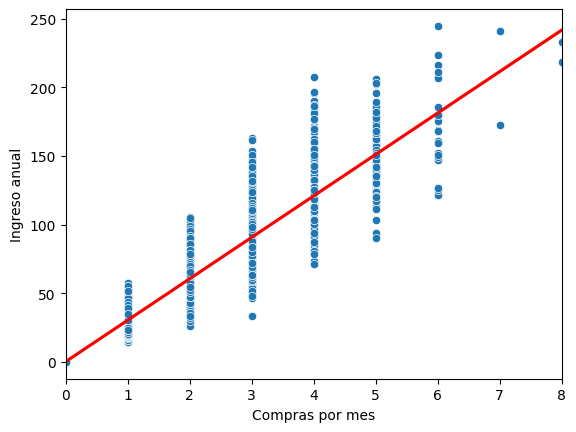

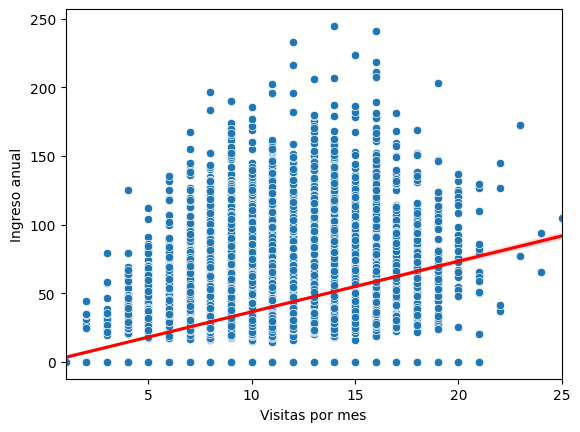

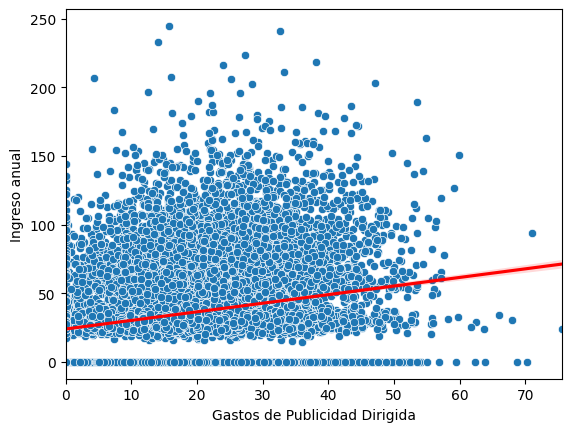

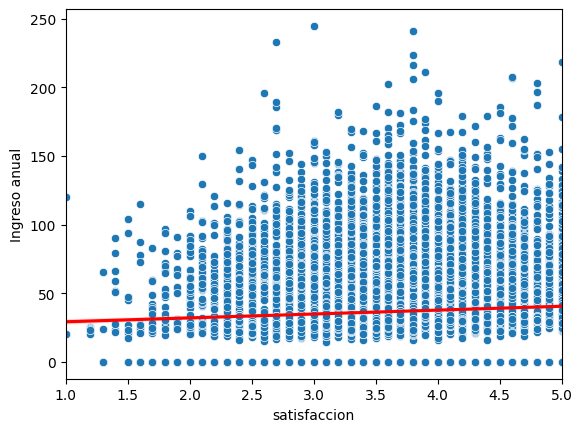

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

#Scatterplot x = compras mes vs y = Ingresos anules
sns.scatterplot(data=df,x='compras_mes',y= 'ingreso_anual')
sns.regplot(data=df, x='compras_mes', y='ingreso_anual',
    scatter=False, color='red')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')
plt.show()

print() # Espacio

#Scatterplot x = visitas mes vs y = Ingresos anules
sns.scatterplot(data=df,x='visitas_mes',y= 'ingreso_anual')
sns.regplot(data=df, x='visitas_mes', y='ingreso_anual',
    scatter=False, color='red')
plt.xlabel('Visitas por mes')
plt.ylabel('Ingreso anual')
plt.show()

print() # Espacio

#Scatterplot x = visitas mes vs y = Ingresos anules
sns.scatterplot(data=df,x='gasto_publicidad_dirigida',y= 'ingreso_anual')
sns.regplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual',
    scatter=False, color='red')
plt.xlabel('Gastos de Publicidad Dirigida')
plt.ylabel('Ingreso anual')
plt.show()

print() # Espacio

#Scatterplot x = visitas mes vs y = Ingresos anules
sns.scatterplot(data=df,x='satisfaccion',y= 'ingreso_anual')
sns.regplot(data=df, x='satisfaccion', y='ingreso_anual',
    scatter=False, color='red')
plt.xlabel('satisfaccion')
plt.ylabel('Ingreso anual')
plt.show()

Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**

-  DIRECCIÓN: Positiva (clara y fuerte)
   La línea roja sube consistentemente de izquierda a derecha.
-  DISPERSIÓN: Baja
   Los puntos están muy concentrados alrededor de la línea de tendencia.
   Hay clustering vertical por cada valor de compras (0, 1, 2, 3... compras/mes).
-  PRESENCIA DE OUTLIERS: Mínimos
   Muy pocos puntos se alejan de la línea roja.
   La mayoría de datos siguen el patrón esperado.
- POSIBLE COLINEALIDAD: ALTA
   Relación casi perfecta (0.97). compras_mes explica casi toda la varianza
   en ingresos_anual. Son prácticamente la misma variable.
   
Es la relación MÁS FUERTE. Lineal casi perfecta.

**visitas_mes vs ingreso_anual**

- DIRECCIÓN: Positiva (débil)
   La línea roja sube, pero el ángulo es muy suave.
- DISPERSIÓN: ALTA
   Los puntos están muy dispersos verticalmente para cada valor de visitas.
   Para visitas=10, ingresos varían entre 0 y 250.
   Hay mucho "ruido" alrededor de la línea.
- PRESENCIA DE OUTLIERS: Muchos
   Hay puntos lejanos arriba y abajo de la línea roja.
   Los outliers son frecuentes, no excepcionales.
- POSIBLE COLINEALIDAD: Baja
   Visitas explica poco de la varianza en ingresos (0.34).
   Muchas otras variables influyen además de visitas.

Relación débil y ruidosa. Lineales pero poco útil para predicción.

**gasto_publicidad_dirigida vs ingreso_anual**

-  DIRECCIÓN: Positiva (casi nula)
   La línea roja es CASI HORIZONTAL. Sube muy poco.
-  DISPERSIÓN: ALTÍSIMA
   Los puntos están completamente dispersos.
   Para gasto=30, ingresos van desde 0 hasta 250.
   No hay patrón visible.
-  PRESENCIA DE OUTLIERS: Abundantes
   Hay muchos puntos lejanos de la línea.
   Los outliers no son excepcionales, son la norma.
-  POSIBLE COLINEALIDAD: Nula
   Gasto en publicidad NO explica ingresos (0.20).
   La relación es prácticamente inexistente.

Relación muy débil, casi nula. Poco útil como predictor.

**satisfaccion vs ingreso_anual**

- DIRECCIÓN: Nula (prácticamente horizontal)
   La línea roja es COMPLETAMENTE PLANA.
   Casi sin pendiente.
- DISPERSIÓN: ALTÍSIMA
   Los puntos están completamente dispersos verticalmente.
   Para satisfacción=3, ingresos van desde 0 hasta 250.
   Hay líneas verticales densas en cada valor de satisfacción.
- PRESENCIA DE OUTLIERS: Abundantes
   Hay muchos puntos lejanos.
   Hay un grupo grande de puntos en ingresos=0 (clientes sin compras).
- POSIBLE COLINEALIDAD: Nula
   Satisfacción NO correlaciona con ingresos (~0.0).
   Son completamente independientes.

NO hay relación. Variable inútil para explicar ingresos.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Columnas para el analisis
columnas_numericas = ['compras_mes', 'visitas_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Funcion para calcular Person / Spearman
def corr_numerica(df, columnas, metodo="pearson"):
    matriz = df[columnas].corr(method=metodo)
    return matriz.style.background_gradient(cmap="coolwarm")

In [ ]:
# Calcular correlación Pearson
print("Correlacion - Pearson")
corr_matriz = corr_numerica(df, columnas_numericas, metodo='pearson')
corr_matriz


Correlacion - Pearson


,compras_mes,visitas_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
compras_mes,1.000000,0.353844,0.207528,-0.003542,0.967149
visitas_mes,0.353844,1.000000,0.578947,-0.003179,0.337147
gasto_publicidad_dirigida,0.207528,0.578947,1.000000,-0.013175,0.197483
satisfaccion,-0.003542,-0.003179,-0.013175,1.000000,0.056171
ingreso_anual,0.967149,0.337147,0.197483,0.056171,1.000000


Observaciones de correlación

**`compras_mes → ingreso_anual`: 0.967**
  DIRECCIÓN: Positiva (muy clara)
  MAGNITUD: FUERTE (casi 1.0 es perfecto)
  COLINEALIDAD: CRÍTICA - Son prácticamente la misma variable

**`visitas_mes → ingreso_anual: 0.337`**
  DIRECCIÓN: Positiva (débil)
  MAGNITUD: DÉBIL-MODERADA (pero significativa)
  COLINEALIDAD: Baja

**`gasto_publicidad_dirigida → ingreso_anual: 0.197`**
  DIRECCIÓN: Positiva (muy suave)
  MAGNITUD: MUY DÉBIL
  COLINEALIDAD: Nula

**`satisfaccion → ingreso_anual: 0.056`**
  DIRECCIÓN: Positiva (prácticamente nula)
  MAGNITUD: PRÁCTICAMENTE NULA
  COLINEALIDAD: Nula

**`compras_mes ↔ visitas_mes: 0.3538`**
  DIRECCIÓN: Positiva moderada
  MAGNITUD: DÉBIL-MODERADA
  COLINEALIDAD: BAJA (r² = 0.125 → explica 12.5% de varianza)
  INTERPRETACIÓN: Tienen cierta relación pero son variables relativamente independientes.
                  No hay problema de colinealidad.

**`visitas_mes ↔ gasto_publicidad_dirigida: 0.5789`**
  DIRECCIÓN: Positiva moderada-fuerte
  MAGNITUD: MODERADA-FUERTE
  COLINEALIDAD: MODERADA (r² = 0.335 → explica 33.5% de varianza)
  INTERPRETACIÓN: Son las variables con mayor colinealidad entre sí.
                  A más visitas, se gasta más en publicidad.
                  Hay redundancia parcial.

**`compras_mes ↔ gasto_publicidad_dirigida: 0.2075`**
  DIRECCIÓN: Positiva débil
  MAGNITUD: MUY DÉBIL
  COLINEALIDAD: BAJA (r² = 0.043 → explica 4.3% de varianza)
  INTERPRETACIÓN: Variables prácticamente independientes.
                  Sin problema de colinealidad.

**La interpretacion y analisis esta bajo correlacion en ningun momentos estamos afirmando causalidad**

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
#importamos pointbiserialr de scipy
from scipy.stats import pointbiserialr

#funcion para point-biserial
def corr_point_biserial(df, col_binaria, columnas_numericas):

        for col in columnas_numericas:
            coef, p_value = pointbiserialr(df[col_binaria],df[col])

            print(f"\nCorrelacion entre: {col_binaria} y {col}")
            print(f"Point-Biserial: {coef:.4f}")

corr_point_biserial(df,'miembro_premium', columnas_numericas)


Correlacion entre: miembro_premium y compras_mes
Point-Biserial: 0.0034

Correlacion entre: miembro_premium y visitas_mes
Point-Biserial: -0.0127

Correlacion entre: miembro_premium y gasto_publicidad_dirigida
Point-Biserial: 0.0027

Correlacion entre: miembro_premium y satisfaccion
Point-Biserial: 0.0257

Correlacion entre: miembro_premium y ingreso_anual
Point-Biserial: 0.0931


Observaciones Punto-biserial

**`miembro_premium vs compras_mes: 0.0034`**
  DIRECCIÓN: Positiva (prácticamente nula)
  MAGNITUD: IRRELEVANTE
  INTERPRETACIÓN: Ser miembro premium NO correlaciona con compras.
                  Los miembros premium compran igual que los no-premium.

**`miembro_premium vs visitas_mes: -0.0127`**
  DIRECCIÓN: Negativa (prácticamente nula)
  MAGNITUD: IRRELEVANTE
  INTERPRETACIÓN: Relación negativa débilísima (casi cero).
                  Si acaso, miembros premium visitan levemente menos.
                  Pero es irrelevante estadísticamente.

**`miembro_premium vs gasto_publicidad_dirigida: 0.0027`**
  DIRECCIÓN: Positiva (prácticamente nula)
  MAGNITUD: IRRELEVANTE
  INTERPRETACIÓN: No hay relación. El gasto en publicidad es igual
                  para premium y no-premium.

**`miembro_premium vs satisfaccion: 0.0257`**
  DIRECCIÓN: Positiva (muy débil)
  MAGNITUD: BAJA (pero es la más fuerte de miembro_premium)
  INTERPRETACIÓN: Ligera tendencia: miembros premium están levemente
                  más satisfechos. Pero muy débil.

**`miembro_premium vs ingreso_anual: 0.0931`**
  DIRECCIÓN: Positiva (débil)
  MAGNITUD: BAJA-MEDIA
  INTERPRETACIÓN: Miembros premium tienen ingresos ligeramente mayores (r=0.0931).
                  Es la correlación MÁS FUERTE de miembro_premium.
                  Pero comparado con compras_mes (0.967), es insignificante.
                  
**El analisis descrito evidencia correlacion NO causalidad**

### V de Cramér

In [ ]:
# Importamos chi2_contingency de Scipy.stats

from scipy.stats import chi2_contingency
import numpy as np
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    return v


In [ ]:
# Aplicar V de Cramér en variables relevantes
cramer_v(df,'region', 'tipo_dispositivo')

0.012378338407739397

Observaciones V de Cramér
**``region vs tipo_dispositivo: 0.0124``**
  MAGNITUD: IRRELEVANTE (cercano a cero)
  DIRECCIÓN: SIN RELACIÓN
  INTERPRETACIÓN: No hay asociación entre región y tipo de dispositivo.
                  La región donde vive el cliente NO afecta qué dispositivo usa.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio
---

### Hallazgo 1: COMPRAS POR MES ES EL FACTOR DETERMINANTE

1. **EVIDENCIA VISUAL:**
   • Scatterplot: Línea diagonal casi perfecta
   • Nube de puntos concentrada alrededor de la línea de tendencia
   • Relación lineal clara y consistente

2. **EVIDENCIA NUMÉRICA:**
   • Correlación de Pearson: 0.9671 (EXCELENTE)
   • R² = 0.9409 → Explica el 94.09% de la varianza en ingresos
   • Pairplot: Patrón diagonal compacto, sin dispersión

3. **INTERPRETACIÓN (sin causalidad):**
   Los clientes que compran más veces por mes están fuertemente asociados
   con ingresos anuales más altos. La relación es casi uno-a-uno:
   a más compras, más ingresos.

4. **NO PODEMOS AFIRMAR:**
   Que más compras CAUSAN más ingresos
   Que aumentar compras automáticamente aumenta ingresos
   La dirección de la causalidad (¿clientes ricos compran más o
      comprar más te hace rico?)

5. **IMPLICACIÓN DE NEGOCIO:**
   compras_mes es el MEJOR indicador del valor del cliente
   Segmentar clientes por frecuencia de compra es estratégico
   Los clientes de alto valor se identifican fácilmente por compras
   Monitorear compras/mes predice ingresos con 94% de precisión
   Enfocar retención en clientes que compran frecuentemente

═══════════════════════════════════════════════════════════════════════════════

### HALLAZGO 2: VISITAS MENSUALES TIENE ASOCIACIÓN DÉBIL

1. **EVIDENCIA VISUAL:**
   • Scatterplot: Nube dispersa alrededor de la línea
   • Puntos separados verticalmente para mismo valor de visitas
   • Línea roja tiene pendiente suave

2. **EVIDENCIA NUMÉRICA:**
   • Correlación de Pearson: 0.3371 (DÉBIL)
   • R² = 0.1156 → Solo explica el 11.56% de la varianza
   • Pairplot: Dispersión alta, relación poco compacta

3. **INTERPRETACIÓN (sin causalidad):**
   Hay una asociación positiva débil entre visitas mensuales e ingresos.
   Clientes que visitan más tienden a tener ingresos ligeramente mayores,
   pero hay mucha variabilidad. No todos los visitantes frecuentes generan
   altos ingresos.

4. **NO PODEMOS AFIRMAR:**
   Que más visitas garantizan ingresos altos
   Que las visitas son predictoras confiables
   Qué causa qué

5. **IMPLICACIÓN DE NEGOCIO:**
   Visitas es un indicador secundario, no principal
   Útil como complemento a compras, no como predictor independiente
   Alta dispersión indica que hay otros factores desconocidos
   No enfocarse solo en aumentar visitas, sino en convertirlas en compras

═══════════════════════════════════════════════════════════════════════════════

### HALLAZGO 3: GASTO EN PUBLICIDAD DIRIGIDA TIENE ASOCIACIÓN MUY DÉBIL

1. **EVIDENCIA VISUAL:**
   • Scatterplot: Línea casi plana, casi horizontal
   • Dispersión altísima, sin patrón definido
   • Puntos dispersos sin agrupamiento

2. **EVIDENCIA NUMÉRICA:**
   • Correlación de Pearson: 0.1975 (MUY DÉBIL)
   • R² = 0.0400 → Solo explica el 4% de la varianza
   • Pairplot: Ruido estadístico, sin estructura

3. **INTERPRETACIÓN (sin causalidad):**
   El gasto en publicidad dirigida tiene asociación mínima con ingresos.
   Clientes con similar inversión en publicidad tienen ingresos muy
   diferentes. El gasto no predice ingresos.

4. **NO PODEMOS AFIRMAR:
   Que el gasto en publicidad genera ingresos
   Que es un factor determinante
   Que aumentar presupuesto mejorará ingresos

5. **IMPLICACIÓN DE NEGOCIO:**
   El ROI de publicidad dirigida es bajo o indirecto
   No es estrategia efectiva para impactar ingresos directamente
   Revisar efectividad de campañas publicitarias
   La publicidad puede servir para traer tráfico, no para generar ingresos directos

═══════════════════════════════════════════════════════════════════════════════

### HALLAZGO 4: SATISFACCIÓN NO TIENE ASOCIACIÓN CON INGRESOS

1. **EVIDENCIA VISUAL:**
   • Scatterplot: Línea prácticamente horizontal
   • Dispersión completa, sin patrón
   • Puntos distribuidos aleatoriamente

2. **EVIDENCIA NUMÉRICA:**
   • Correlación de Pearson: 0.0562 (NULA)
   • R² = 0.0032 → Explica solo el 0.31% de la varianza
   • P-value > 0.05 → Estadísticamente no significativo

3. **INTERPRETACIÓN (sin causalidad):**
   No hay relación entre satisfacción y ingresos anuales.
   Clientes muy satisfechos y poco satisfechos generan ingresos similares.
   Estas variables son completamente independientes.

4. **NO PODEMOS AFIRMAR:**
   Que más satisfacción genera más ingresos
   Que insatisfacción reduce ingresos
   Que están relacionadas de alguna forma

5. **IMPLICACIÓN DE NEGOCIO:**
   HALLAZGO CRÍTICO: Satisfacción ≠ Lealtad / Ingresos
   Los clientes satisfechos NO generan más ingresos
   Es posible tener clientes satisfechos pero que compren poco
   Metrics de satisfacción NO predicen desempeño financiero
   Revisar estrategia de satisfacción del cliente (puede estar desalineada)

═══════════════════════════════════════════════════════════════════════════════

### HALLAZGO 5: MEMBRESÍA PREMIUM NO DIFERENCIA CLIENTES

1. **EVIDENCIA VISUAL:**
   • No hay separación clara entre premium y no-premium en distribuciones
   • Ambos grupos se superponen completamente

2. **EVIDENCIA NUMÉRICA:**
   • Point-Biserial vs ingresos: 0.0931 (DÉBIL)
   • Point-Biserial vs compras: 0.0034 (NULA)
   • Point-Biserial vs visitas: -0.0127 (NULA)

3. **INTERPRETACIÓN (sin causalidad):**
   El estatus premium no está asociado con diferentes comportamientos
   de compra o ingresos. Miembros premium y no-premium se comportan
   de manera similar.

4. **NO PODEMOS AFIRMAR:**
   Que ser premium afecta comportamiento
   Que el programa premium funciona

5. **IMPLICACIÓN DE NEGOCIO:**
   El programa de membresía premium NO está diferenciando clientes
   Los miembros premium compran lo mismo que no-premium
   Programa puede no estar aportando valor
   Revisar beneficios y atractivo de membresía
   Considerar rediseño del programa

═══════════════════════════════════════════════════════════════════════════════

### HALLAZGO 6: REGIÓN Y DISPOSITIVO SON INDEPENDIENTES

1. **EVIDENCIA NUMÉRICA:**
   • V de Cramér: 0.0124 (NULA)
   • No hay asociación entre dónde vive el cliente y qué dispositivo usa

2. **INTERPRETACIÓN (sin causalidad):**
   El comportamiento de dispositivo no varía por región geográfica.

3. **IMPLICACIÓN DE NEGOCIO:**
   Estrategia de dispositivo debe ser uniforme, no regional
   El 65% usa móvil en TODAS las regiones
   Optimización mobile es crítica globalmente, no solo en regiones específicas


## Sección 6 - Limitaciones y próximos pasos

### 7.1. LIMITACIONES DEL ANÁLISIS

* Correlación ≠ causalidad
  Las asociaciones encontradas no implican relación causa-efecto.
  No sabemos si compras generan ingresos o si ingresos altos permiten más compras.

* Colinealidad casi perfecta en compras_mes e ingresos_anual
  r = 0.967 sugiere que son prácticamente la misma variable.
  Podría ser que ingresos_anual sea simplemente = compras_mes × constante.
  Necesita validación del negocio.

* Falta de variables contextuales
  No hay información sobre: precio promedio de productos, estacionalidad,
  cambios en políticas, competencia, campañas específicas, etc.
  Esto puede explicar la baja correlación de publicidad y satisfacción.

* Datos transversales (sin tiempo)
  El análisis es de un momento específico. No sabemos patrones a lo largo del tiempo.
  Un cliente puede haber comprado 8 veces este mes pero 0 veces el anterior.

* Variables demográficas ausentes
  Edad, nivel_ingreso no correlacionan con nada.
  Falta información sobre: género, ocupación, sector, tamaño de empresa, etc.

* Satisfacción puede estar mal medida
  Escala 1-5 puede no capturar la experiencia real.
  O los clientes pueden responder aleatoriamente sin relación a compras.

* Programa premium sin tracción
  90% de clientes son no-premium. Muestra desbalanceada para análisis.
  No hay suficientes datos premium para conclusiones firmes.

* R² = 0.94 en compras vs ingresos es SOSPECHOSAMENTE alto
  Sugiere que:
  a) Son medidas redundantes, o
  b) Hay una fórmula directa entre ellas (posible error de medición)
  Requiere auditoría de datos.

═══════════════════════════════════════════════════════════════════════════════

### PRÓXIMOS PASOS

[PASO 1: VALIDACIÓN DE DATOS]

* Auditar relación compras_mes vs ingresos_anual
  Verificar si ingresos_anual = compras_mes × precio_promedio
  Si es así, eliminar redundancia. Si no, investigar anomalía.

* Revisar consistencia de datos de satisfacción
  ¿Los clientes respondieron realmente o fue automático?
  Comparar con satisfacción de otros canales (NPS, reviews, etc.)

* Verificar completitud de variables categóricas
  ¿Hay valores nulos o mal clasificados en región, dispositivo, premium?

═══════════════════════════════════════════════════════════════════════════════

[PASO 2: ANÁLISIS DE SEGMENTACIÓN AVANZADA]

* Segmentación por cuartiles de compras
  Crear 4 grupos (clientes bajo, medio-bajo, medio-alto, alto compradores)
  Analizar características de cada grupo. ¿Qué hace que unos compren más?

* Clustering K-means con variables comportamentales
  Agrupar clientes automáticamente por compras, visitas, gasto publicidad
  Identificar perfiles de clientes naturales (no predefinidos como premium)

* Análisis de cohesión: premium vs no-premium
  Ya que miembro_premium no funciona, investigar por qué.
  ¿Cómo se asigna membership? ¿Hay criterios claros?
  ¿Es una compra adicional del cliente o un atributo independiente?

═══════════════════════════════════════════════════════════════════════════════

[PASO 3: ANÁLISIS DE VARIABLE DEPENDIENTE]

* Chi-cuadrado: región vs ingresos_anual (categorizar)
  Convertir ingresos a categorías (bajo, medio, alto)
  Testear si región influye en nivel de ingresos

* Chi-cuadrado: tipo_dispositivo vs compras_mes (categorizar)
  ¿Los usuarios de móvil compran diferente que usuarios de desktop?
  Verificar si dispositivo afecta comportamiento de compra

* ANOVA: Ingresos por región, por dispositivo
  Teste parametrico para ver diferencias de medias entre grupos